# **Grande étude sur l'alimentation et la sous-nutrition dans le monde**

Produire une série de diverses analyses dans le cadre d'une étude majeure sur la thématique de l'alimentation et la sous-nutrition au niveau mondial

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import spearmanr

In [ ]:
# import the main csv as dataframe
file = "data/"
df_aide_alimentaire = pd.read_csv(f'{file}aide_alimentaire.csv')
df_dispo_alimentaire = pd.read_csv(f'{file}dispo_alimentaire.csv')
df_population = pd.read_csv(f'{file}population.csv')
df_sous_nutrition = pd.read_csv(f'{file}sous_nutrition.csv')

Au cours des trois prochaines parties, nous procéderons à une exploration détaillée de chaque jeu de données. Cette phase initiale cruciale consiste à en examiner la structure interne, le nombre d’enregistrements, les types de données et les valeurs nulles, éléments fondamentaux pour assurer de façon efficace la qualité des données.

## **Aide alimentaire dataset exploration**

In [ ]:
df_aide_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pays bénéficiaire  1475 non-null   object
 1   Année              1475 non-null   int64 
 2   Produit            1475 non-null   object
 3   Valeur             1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


In [ ]:
df_aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


Le jeu de données semble bien structuré pour l'exploitation. Quelques colonnes pourraient toutefois être renommées afin d'être mieux identifiées par la suite.

In [ ]:
df_aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Pays', "Valeur": "Aide alimentaire (en Tonnes)"}, inplace=True)

La valeur «Valeur» n'était pas très adaptée à ce cas, aussi l'ai-je renommée en «Aide alimentaire (en millier de T)», afin d'identifier plus clairement l'unité de mesure et son objectif.

In [ ]:
print(df_aide_alimentaire["Pays"].nunique())
print(df_aide_alimentaire["Pays"].unique().tolist())

76
['Afghanistan', 'Algérie', 'Angola', 'Bangladesh', 'Bénin', 'Bhoutan', 'Bolivie (État plurinational de)', 'Burkina Faso', 'Burundi', 'Cambodge', 'Cameroun', 'Chine, continentale', 'Colombie', 'Comores', 'Congo', "Côte d'Ivoire", 'Cuba', 'Djibouti', 'Égypte', 'El Salvador', 'Équateur', 'Éthiopie', 'Gambie', 'Géorgie', 'Ghana', 'Guatemala', 'Guinée', 'Guinée-Bissau', 'Haïti', 'Honduras', "Iran (République islamique d')", 'Iraq', 'Jordanie', 'Kenya', 'Kirghizistan', 'Lesotho', 'Liban', 'Libéria', 'Libye', 'Madagascar', 'Malawi', 'Mali', 'Mauritanie', 'Mozambique', 'Myanmar', 'Népal', 'Nicaragua', 'Niger', 'Ouganda', 'Pakistan', 'Palestine', 'Philippines', 'République arabe syrienne', 'République centrafricaine', 'République démocratique du Congo', 'République démocratique populaire lao', 'République dominicaine', 'République populaire démocratique de Corée', 'République-Unie de Tanzanie', 'Rwanda', 'Sao Tomé-et-Principe', 'Sénégal', 'Sierra Leone', 'Somalie', 'Soudan', 'Soudan du Sud',

In [ ]:
print(df_aide_alimentaire["Année"].nunique())
print(df_aide_alimentaire["Année"].unique().tolist())

4
[2013, 2014, 2015, 2016]


L'inspection des lignes dupliquées est important pour maintenir l'intégrité des données et éviter tous résultats biaisés pendant l'analyse et la consolidation des données.

In [ ]:
print(f"Nombre de lignes dupliquées: {df_aide_alimentaire[["Pays", "Année", "Produit"]].duplicated().sum()}")

Nombre de lignes dupliquées: 0


Aucunes lignes dupliqués détéctés

**Répartition du prix et détection des outliers pour la valeur "Aide alimentaire (en Tonnes)"**

<Axes: >

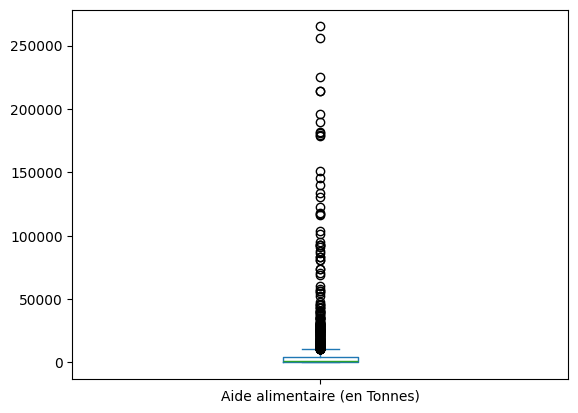

In [ ]:
df_aide_alimentaire["Aide alimentaire (en Tonnes)"].plot(kind="box")

## **Disponibilité alimentaire**

In [ ]:
df_dispo_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  object 
 1   Produit                                                        15605 non-null  object 
 2   Origine                                                        15605 non-null  object 
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de matière grasse en quantité (g/personne/jo

In [ ]:
df_dispo_alimentaire.rename(columns={"Zone": "Pays"}, inplace=True)

In [ ]:
df_dispo_alimentaire.head()

,Pays,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df_dispo_alimentaire.isna().sum())

Pays                                                                 0
Produit                                                              0
Origine                                                              0
Aliments pour animaux                                            12885
Autres Utilisations                                              10109
Disponibilité alimentaire (Kcal/personne/jour)                    1364
Disponibilité alimentaire en quantité (kg/personne/an)            1590
Disponibilité de matière grasse en quantité (g/personne/jour)     3811
Disponibilité de protéines en quantité (g/personne/jour)          4044
Disponibilité intérieure                                           223
Exportations - Quantité                                           3379
Importations - Quantité                                            753
Nourriture                                                        1590
Pertes                                                           11327
Produc

In [ ]:
df_dispo_alimentaire.fillna(0, inplace=True)

In [ ]:
print(df_dispo_alimentaire.nunique())

Pays                                                              174
Produit                                                            98
Origine                                                             2
Aliments pour animaux                                             537
Autres Utilisations                                               406
Disponibilité alimentaire (Kcal/personne/jour)                    560
Disponibilité alimentaire en quantité (kg/personne/an)           2918
Disponibilité de matière grasse en quantité (g/personne/jour)    1126
Disponibilité de protéines en quantité (g/personne/jour)         1034
Disponibilité intérieure                                         1794
Exportations - Quantité                                           761
Importations - Quantité                                           870
Nourriture                                                       1395
Pertes                                                            433
Production          

In [ ]:
print(f"Nombre de lignes dupliquées: {df_dispo_alimentaire[["Pays", "Produit", "Origine"]].duplicated().sum()}")

Nombre de lignes dupliquées: 0


Conversion des données exprimées en millier de T en kg pour une meilleure interprétation et comparaison des données

In [ ]:
cols_to_take = np.r_[3:5, 9:18]
df_dispo_alimentaire.iloc[:, cols_to_take] =  df_dispo_alimentaire.iloc[:, cols_to_take] * 1000

Est-ce qu'il existe des valeurs dites "outliers" ?

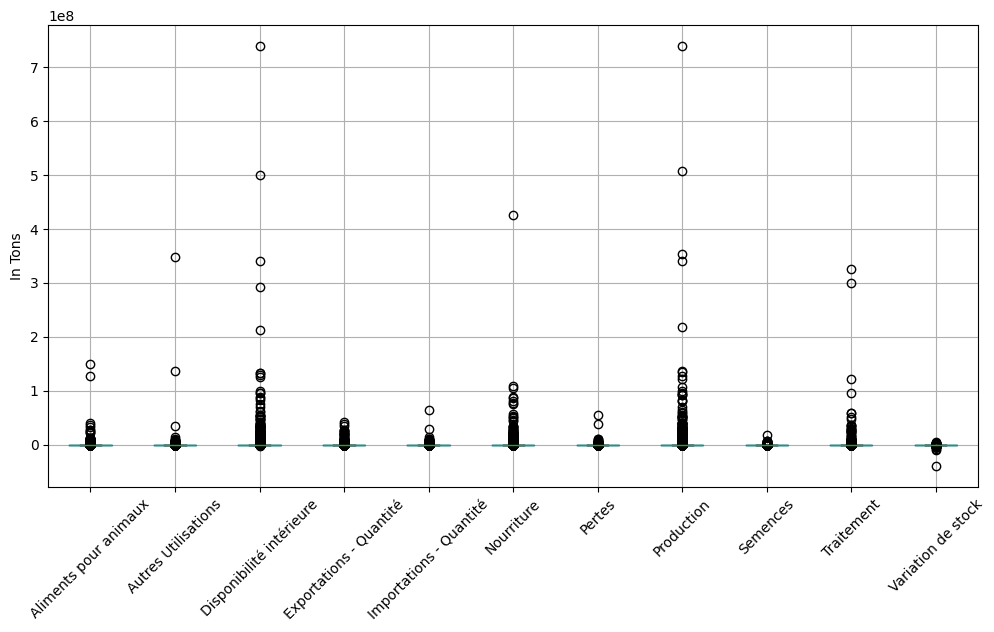

In [ ]:
plt.figure(figsize=(12,6))
df_dispo_alimentaire.iloc[:, cols_to_take].boxplot()
plt.ylabel("In Tons")
plt.xticks(rotation=45)
plt.show()

## **Population**

In [ ]:
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


Pas de valeurs nulles

In [ ]:
columns_to_replace = {"Zone": "Pays", "Valeur": "Population"}
df_population.rename(columns=columns_to_replace, inplace=True)

In [ ]:
df_population.head()

,Pays,Année,Population
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [ ]:
df_population["Population"] = df_population["Population"] * 1000

Ici, il est important de vérifier s'il existe des valeurs dupliquées surtout sur les champs "Pays" et "Année", car ils seront utilisés comme jointure pour les autres dataset.

In [ ]:
print(f"Number of duplicated lines : {df_population[["Pays", "Année"]].duplicated().sum()}")

Number of duplicated lines : 0


## **Sous-nutrition**

In [ ]:
df_sous_nutrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB


In [ ]:
df_sous_nutrition.rename(columns={"Zone": "Pays", "Valeur": "Population en sous-nutrition"}, inplace=True)

In [ ]:
df_sous_nutrition.head()

,Pays,Année,Population en sous-nutrition
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [ ]:
print(f"Number of duplicated lines : {df_sous_nutrition[["Pays", "Année"]].duplicated().sum()}")

Number of duplicated lines : 0


Vérifions s'il existe des valeurs qui ne sont pas numériques

In [ ]:
print(df_sous_nutrition["Population en sous-nutrition"].value_counts())

Population en sous-nutrition
<0.1    120
0.3      48
0.4      32
0.2      28
1.5      20
       ... 
4.1       1
14.1      1
2.6       1
8         1
8.3       1
Name: count, Length: 139, dtype: int64


Les valeurs < 0.1 seront exclues car trop faibles pour être analysé

In [ ]:
df_sous_nutrition[df_sous_nutrition["Population en sous-nutrition"] == "<0.1"] = 0
df_sous_nutrition["Population en sous-nutrition"] = df_sous_nutrition["Population en sous-nutrition"].astype(float) * 1000000

In [ ]:
df_sous_nutrition["Année"].value_counts()

,count
Année,
2017-2019,184
2014-2016,183
2012-2014,183
2016-2018,183
2015-2017,183
2013-2015,182
0,120


In [ ]:
df_sous_nutrition[df_sous_nutrition["Année"] == 0]

,Pays,Année,Population en sous-nutrition
60,0,0,0.0
61,0,0,0.0
62,0,0,0.0
63,0,0,0.0
64,0,0,0.0
...,...,...,...
1183,0,0,0.0
1184,0,0,0.0
1185,0,0,0.0
1186,0,0,0.0


In [ ]:
df_sous_nutrition = df_sous_nutrition.loc[df_sous_nutrition["Année"] != 0, :]

In [ ]:
year_split = df_sous_nutrition["Année"].str.split("-")
year_start = year_split.str[0].astype(int)
year_end = year_split.str[1].astype(int)
df_sous_nutrition["Année médian"] = (year_end + year_start) / 2
df_sous_nutrition["Année médian"] = df_sous_nutrition["Année médian"].astype(int)
df_sous_nutrition

,Pays,Année,Population en sous-nutrition,Année médian
0,Afghanistan,2012-2014,8600000.0,2013
1,Afghanistan,2013-2015,8800000.0,2014
2,Afghanistan,2014-2016,8900000.0,2015
3,Afghanistan,2015-2017,9700000.0,2016
4,Afghanistan,2016-2018,10500000.0,2017
...,...,...,...,...
1213,Zimbabwe,2013-2015,NaN,2014
1214,Zimbabwe,2014-2016,NaN,2015
1215,Zimbabwe,2015-2017,NaN,2016
1216,Zimbabwe,2016-2018,NaN,2017


Vérifions maitenant les valeurs nulles pour chaque valeur

In [ ]:
print(df_sous_nutrition.isna().sum())

Pays                              0
Année                             0
Population en sous-nutrition    594
Année médian                      0
dtype: int64


In [ ]:
df_sous_nutrition["Population en sous-nutrition"] = df_sous_nutrition["Population en sous-nutrition"].fillna(0)

Pour simplifier le traitement, toutes les valeurs nulles seront remplacées par 0 car comme chaque pays est indépendant, nous ne pouvons pas remplacer les valeurs par la médiane ou la moyenne.

In [ ]:
df_sous_nutrition.fillna(0, inplace=True)

Put the Population feature at the right scale: Thousands to Millions

## **Fusion des tables**

### **Sous-nutrition et population**

"Population" et "Sous-nutrition" seront fusionnées pour faciliter la création et l'analyse de nouveaux métriques comme le taux de sous-nutrition par exemple

In [ ]:
df_sous_nutrition2017 = df_sous_nutrition[df_sous_nutrition["Année médian"]==2017]

In [ ]:
df_sous_nutrition_population = pd.merge(df_population,
                                        df_sous_nutrition2017,
                                        on="Pays",
                                        indicator=True)

In [ ]:
df_sous_nutrition_population

,Pays,Année_x,Population,Année_y,Population en sous-nutrition,Année médian,_merge
0,Afghanistan,2013,32269589.0,2016-2018,10500000.0,2017,both
1,Afghanistan,2014,33370794.0,2016-2018,10500000.0,2017,both
2,Afghanistan,2015,34413603.0,2016-2018,10500000.0,2017,both
3,Afghanistan,2016,35383032.0,2016-2018,10500000.0,2017,both
4,Afghanistan,2017,36296113.0,2016-2018,10500000.0,2017,both
...,...,...,...,...,...,...,...
1093,Zimbabwe,2014,13586707.0,2016-2018,0.0,2017,both
1094,Zimbabwe,2015,13814629.0,2016-2018,0.0,2017,both
1095,Zimbabwe,2016,14030331.0,2016-2018,0.0,2017,both
1096,Zimbabwe,2017,14236595.0,2016-2018,0.0,2017,both


In [ ]:
df_sous_nutrition_population.duplicated().sum()

np.int64(0)

Pas de valeurs nulles et non-dupliquées

## **Disponibilité alimentaire et Population**

In [ ]:
df_population_2017 = df_population[df_population["Année"]==2017]

In [ ]:
df_dispo_alimentaire_population = pd.merge(df_population_2017,
                                     df_dispo_alimentaire,
                                     on="Pays",
                                     indicator=True)

In [ ]:
df_dispo_alimentaire_population

,Pays,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,_merge
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,...,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0,both
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,...,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,both
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,...,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,both
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,...,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Zimbabwe,2017,14236595.0,Viande de Suides,animale,0.0,0.0,24.0,2.65,2.25,...,37000.0,0.0,6000.0,37000.0,0.0,32000.0,0.0,0.0,0.0,both
15412,Zimbabwe,2017,14236595.0,Viande de Volailles,animale,0.0,0.0,17.0,4.97,1.05,...,70000.0,0.0,6000.0,70000.0,0.0,64000.0,0.0,0.0,0.0,both
15413,Zimbabwe,2017,14236595.0,"Viande, Autre",animale,0.0,1000.0,7.0,2.29,0.21,...,34000.0,3000.0,1000.0,32000.0,0.0,36000.0,0.0,0.0,0.0,both
15414,Zimbabwe,2017,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,...,4000.0,0.0,2000.0,4000.0,0.0,2000.0,0.0,0.0,0.0,both


In [ ]:
df_dispo_alimentaire_population.duplicated().sum()

np.int64(0)

Pas d'éléments dupliqués

## **Sous-nutrition et Disponibilité alimentaire**

In [ ]:
# let's filter out the undernourishment dataset to retrieve the year 2017
df_sous_nutrition_2017 = df_sous_nutrition[df_sous_nutrition["Année médian"]==2017]

In [ ]:
df_sous_nutrition_disponibilite = pd.merge(
    df_sous_nutrition_2017,
    df_dispo_alimentaire,
    on="Pays",
    indicator=True
)

In [ ]:
df_sous_nutrition_disponibilite.duplicated().sum()

np.int64(0)

Pas d'éléments dupliqués

## **Analyse: Aide alimentaire**

Cette partie vise à visualiser les denrées alimentaires qui ont fait partie de l'aide alimentaire

In [ ]:
df_aide_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Pays                          1475 non-null   object
 1   Année                         1475 non-null   int64 
 2   Produit                       1475 non-null   object
 3   Aide alimentaire (en Tonnes)  1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


In [ ]:
product_aid = df_aide_alimentaire.groupby("Produit")["Aide alimentaire (en Tonnes)"].sum()

In [ ]:
top_product_aid = product_aid.sort_values(ascending=False).head(5)

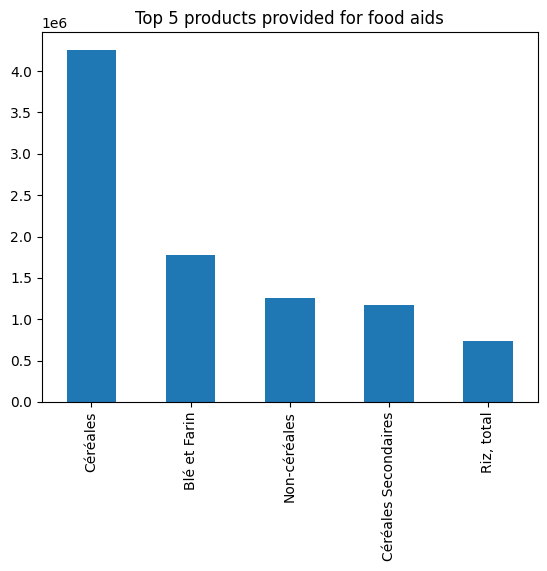

In [ ]:
top_product_aid.plot(kind="bar")
plt.title("Top 5 products provided for food aids")
plt.xlabel("")
plt.show()

Les céréales sont les produits les plus sollicités par l'aide alimentaire

## **Evolution des denrées les plus sollicités par l'aide alimentaire**

In [ ]:
top_product_aid_list = top_product_aid.index.to_list()
top_product_aid_list

['Céréales',
 'Blé et Farin',
 'Non-céréales',
 'Céréales Secondaires',
 'Riz, total']

In [ ]:
top_products_years = df_aide_alimentaire[
    df_aide_alimentaire["Produit"].isin(top_product_aid_list)
]

In [ ]:
pivot_top_products_years = top_products_years.pivot_table(
    index="Année",
    columns="Produit",
    values="Aide alimentaire (en Tonnes)",
    aggfunc="sum"
)

Pivoter la table est ici important pour afficher chaque produit en légende lors de la création du graphique

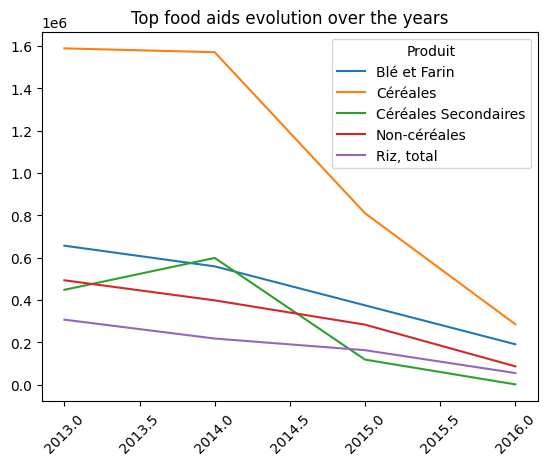

In [ ]:
pivot_top_products_years.plot()
plt.xticks(rotation=45)
plt.xlabel("")
plt.title("Top food aids evolution over the years")
plt.show()

De manière générale, l'aide alimentaire a bien diminué entre 2013 et 2016. Les céréales sont les denrées qui ont connu la plus forte baisse passant de 1.6M Tonnes en 2013 à moins de 0.5M Tonnes en 2016. Le volume d'aide alimentaire pour tous les autres produits ont aussi diminué de manière plus graduel, chutant de près de la moitié au cours des 3 années.

## **Analyse: Personnes en situation de sous-nutrition à travers le monde**


Cette partie met en lumière les pays avec le taux de sous-nutrition le plus élevé.

In [ ]:
df_sous_nutrition_population

,Pays,Année_x,Population,Année_y,Population en sous-nutrition,Année médian,_merge
0,Afghanistan,2013,32269589.0,2016-2018,10500000.0,2017,both
1,Afghanistan,2014,33370794.0,2016-2018,10500000.0,2017,both
2,Afghanistan,2015,34413603.0,2016-2018,10500000.0,2017,both
3,Afghanistan,2016,35383032.0,2016-2018,10500000.0,2017,both
4,Afghanistan,2017,36296113.0,2016-2018,10500000.0,2017,both
...,...,...,...,...,...,...,...
1093,Zimbabwe,2014,13586707.0,2016-2018,0.0,2017,both
1094,Zimbabwe,2015,13814629.0,2016-2018,0.0,2017,both
1095,Zimbabwe,2016,14030331.0,2016-2018,0.0,2017,both
1096,Zimbabwe,2017,14236595.0,2016-2018,0.0,2017,both


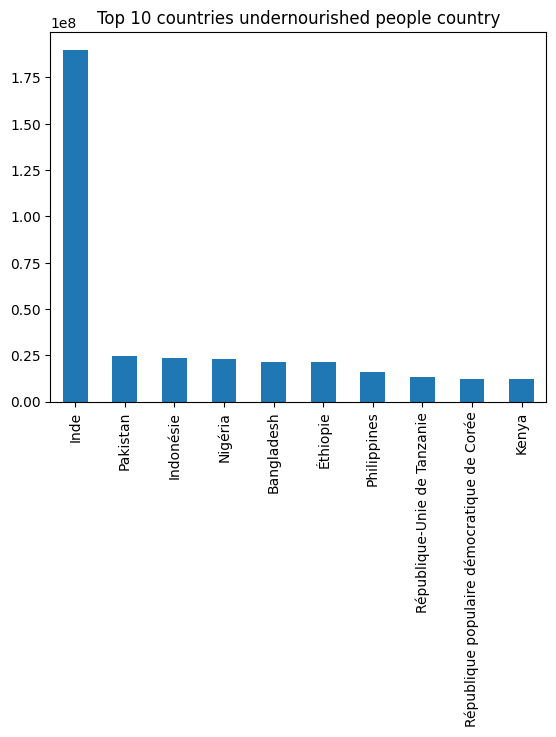

In [ ]:
people_undernourished_country = df_sous_nutrition_population.groupby("Pays")\
 ["Population en sous-nutrition"].mean()\
.sort_values(ascending=False).head(10)

plot_people_undernourished_country = people_undernourished_country.plot(kind="bar")
plt.title("Top 10 countries undernourished people country")
plt.xlabel("")
plt.show()

people_undernourished_country = people_undernourished_country.reset_index()

L'Inde présente le taux de sous-alimentation le plus élevé, de loin; toutefois, son importance numérique déforme la distribution globale lorsqu'on la compare aux autres pays. Les pays restants affichent une répartition plus homogène, généralement composée de nations à infrastructure limitée, souvent insuffisante pour garantir la sécurité alimentaire de l'ensemble de leur population.

Nous allons utiliser la métrique de la population afin de calculer l'indicateur entre la population totale du pays et la population sous-alimentée, afin de fournir un indicateur clair et pertinent des enjeux de sécurité alimentaire.

In [ ]:
df_sous_nutrition_population["Taux population en sous-nutrition"] = \
df_sous_nutrition_population["Population en sous-nutrition"] / df_sous_nutrition_population["Population"]

In [ ]:
undernourished_population_rate = df_sous_nutrition_population.groupby("Pays", as_index=False)["Taux population en sous-nutrition"].mean()

In [ ]:
top_undernourished_population_rate = undernourished_population_rate.sort_values("Taux population en sous-nutrition", ascending=False).head(10)

<Axes: xlabel='Pays'>

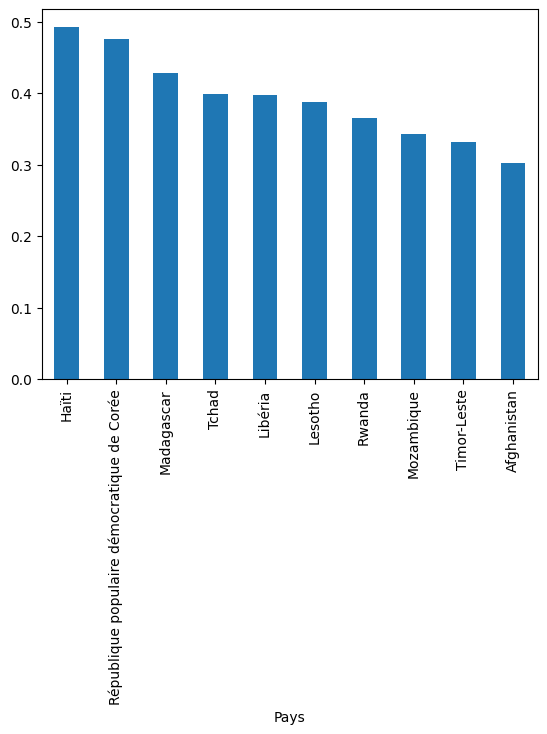

In [ ]:
top_undernourished_population_rate.plot(
    kind="bar",
    x="Pays",
    y="Taux population en sous-nutrition",
    legend=False
)

In [ ]:
worlwide_undernourished_people = people_undernourished_country["Population en sous-nutrition"].sum()
print(worlwide_undernourished_people)

356900000.0


In [ ]:
worlwide_population = df_sous_nutrition_population.groupby("Pays")["Population"].mean().sum()
print(worlwide_population)

7402715581.166666


In [ ]:
worlwide_undernourished_people_rate = worlwide_undernourished_people / worlwide_population
print(f"{worlwide_undernourished_people_rate*100: .1f}% de la population mondiale en situation de sous-nutrition")

 4.8% worlwide undernourished population


## **Analyse: Disponibilité alimentaire**

Nous devons filtrer les données pour l’année 2017, car les informations sur la disponibilité alimentaire sont exclusivement basées sur les enregistrements de cette année-là.

In [ ]:
df_dispo_alimentaire_population_2017 = df_dispo_alimentaire_population[
    df_dispo_alimentaire_population["Année"] == 2017]
df_dispo_alimentaire_population_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15416 entries, 0 to 15415
Data columns (total 21 columns):
 #   Column                                                         Non-Null Count  Dtype   
---  ------                                                         --------------  -----   
 0   Pays                                                           15416 non-null  object  
 1   Année                                                          15416 non-null  int64   
 2   Population                                                     15416 non-null  float64 
 3   Produit                                                        15416 non-null  object  
 4   Origine                                                        15416 non-null  object  
 5   Aliments pour animaux                                          15416 non-null  float64 
 6   Autres Utilisations                                            15416 non-null  float64 
 7   Disponibilité alimentaire (Kcal/personne/jour)   

New merged dataset overview

In [ ]:
df_dispo_alimentaire_population_2017

,Pays,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,_merge
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,...,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0,both
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,...,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,both
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,...,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,both
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,...,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Zimbabwe,2017,14236595.0,Viande de Suides,animale,0.0,0.0,24.0,2.65,2.25,...,37000.0,0.0,6000.0,37000.0,0.0,32000.0,0.0,0.0,0.0,both
15412,Zimbabwe,2017,14236595.0,Viande de Volailles,animale,0.0,0.0,17.0,4.97,1.05,...,70000.0,0.0,6000.0,70000.0,0.0,64000.0,0.0,0.0,0.0,both
15413,Zimbabwe,2017,14236595.0,"Viande, Autre",animale,0.0,1000.0,7.0,2.29,0.21,...,34000.0,3000.0,1000.0,32000.0,0.0,36000.0,0.0,0.0,0.0,both
15414,Zimbabwe,2017,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,...,4000.0,0.0,2000.0,4000.0,0.0,2000.0,0.0,0.0,0.0,both


Y a t-il des lignes dupliquées ?

In [ ]:
df_dispo_alimentaire_population_2017.duplicated().sum()

np.int64(0)

Total KCal yearly * population / population


Cette section présente un ensemble de fonctions utilitaires conçues pour simplifier les calculs répétitifs. Ces fonctions permettront de calculer le nombre de personnes suffisamment nourries, y compris un ratio qui gère soigneusement les cas de division par zéro, et de déterminer dynamiquement le nombre de lignes pour les graphiques en fonction du nombre d'éléments souhaités.

In [ ]:
def calculate_number_people_nourrished(df, col1, col2, kcal_daily):
  """Calculates the total number of people who could be nourished.

  This function multiplies two specified columns from a DataFrame, sums the
  result, and then divides by a daily caloric requirement to estimate
  the number of people who could be nourished.

  Args:
    df (pandas.DataFrame): The input DataFrame containing food availability
      and population data.
    col1 (str): The name of the column representing daily caloric availability
      per person (e.g., 'Disponibilité alimentaire (Kcal/personne/jour)').
    col2 (str): The name of the column representing the population
      (e.g., 'Population').
    kcal_daily (int/float): The average daily caloric requirement per person.

  Returns:
    float: The calculated total number of people who could be nourished.
  """
  worlwide = df[col1] * df_dispo_alimentaire_population_2017[col2]
  worlwide = worlwide.sum()
  return worlwide/kcal_daily

def calculate_ratio(value1, value2):
  """Calculates the ratio of two numerical values.

  Args:
    value1 (int/float): The numerator.
    value2 (int/float): The denominator.

  Returns:
    float: The ratio `value1 / value2`.
  """
  try:
    result = value1 / value2
  except ZeroDivisionError:
    result=None
    print("Cannot divide by 0")
  return result

def nrows_plot(n_cols, n_elements):
  """Calculates the number of rows needed for a subplot grid.

  This function determines the number of rows required for a subplot grid
  given the number of columns and the total number of elements.

  Args:
    n_cols (int): The desired number of columns in the subplot grid.
    n_elements (int): The total number of elements (plots) to be displayed.

  Returns:
    int: The calculated number of rows required for the subplot grid.
  """
  try:
    return math.ceil(n_elements/n_cols)
  except ZeroDivisionError:
    return None

Pour calculer le nombre de personnes qui pourraient potentiellement être nourries grâce à une distribution alimentaire mondiale plus équitable, nous pouvons établir une valeur moyenne de besoins caloriques journaliers par personne. En considérant qu'un homme a généralement besoin de 2500 kcal par jour et qu'une femme de 2000 kcal par jour, une moyenne de 2250 kcal sera utilisée.

In [ ]:
daily_kcal_needed = 2250

In [ ]:
worldwide_daily_food_availibility = calculate_number_people_nourrished(df_dispo_alimentaire_population_2017,
                                                                       "Disponibilité alimentaire (Kcal/personne/jour)",
                                                                       "Population",
                                                                       daily_kcal_needed
                                                                       )
worldwide_daily_food_availibility

np.float64(9297326501.036)

In [ ]:
ratio_people_nourrished = worldwide_daily_food_availibility \
/ df_dispo_alimentaire_population_2017.groupby("Pays")["Population"].first().sum()
ratio_people_nourrished

np.float64(1.275020974337085)

We could satisfy 1.27 times the total population depending on the total number of worlwide available foods
On pourrait nourrir jusqu'à 1.27 fois la population mondiale si l'alimentation était équitablement répartie entre les pays.

Ici, illustrons le même processus avec les produits végétaux. Combien de personnes pourraient être nourries uniquement à partir de produits d’origine non animale ?

In [ ]:
df_dispo_alimentaire_population_2017_vegetables = df_dispo_alimentaire_population_2017.loc[
    df_dispo_alimentaire_population_2017["Origine"] == "vegetale", :
]

In [ ]:
worldwide_daily_food_vegetables_availibility = calculate_number_people_nourrished(
    df_dispo_alimentaire_population_2017_vegetables,
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Population",
     daily_kcal_needed
)

In [ ]:
ratio_people_nourrished_vegetables = worldwide_daily_food_vegetables_availibility / df_dispo_alimentaire_population_2017.groupby("Pays")["Population"].first().sum()
ratio_people_nourrished_vegetables

np.float64(1.0520508903666907)

Avec seulement de l'alimentation végétale, nous pourrions nourrir jusqu'à 1.05 fois la population mondiale

# **Répartition de la disponibilité alimentaire**

Cette section présente principalement la manière dont la nourriture est équilibrée au sein de chaque pays. Nous distinguons, par exemple, la production, les importations, les stocks et la quantité de nourriture disponible à destination des humains ou des animaux.
Nous allons ensuite visualiser la façon dont ces indicateurs se répartissent entre les deux grands groupes qui composent la disponibilité alimentaire du pays.

## **Régle de distribution de la distribution alimentaire ?**

In [ ]:
group1_labels = ["Production", "Importations - Quantité", "Exportations - Quantité", "Variation de stock"]
group2_labels = ["Semences", "Pertes", "Nourriture", "Aliments pour animaux", "Autres Utilisations"]

Nous allons convertir en valeur absolue les deux groupes pour éviter toutes valeurs négatives, non pertinents pour la création d'un diagramme de répartition

In [ ]:
group_1_inner_food_availibility = [abs(df_dispo_alimentaire[group].sum()) for group in group1_labels]

group_2_inner_food_availibility = [abs(df_dispo_alimentaire[group].sum()) for group in group2_labels]

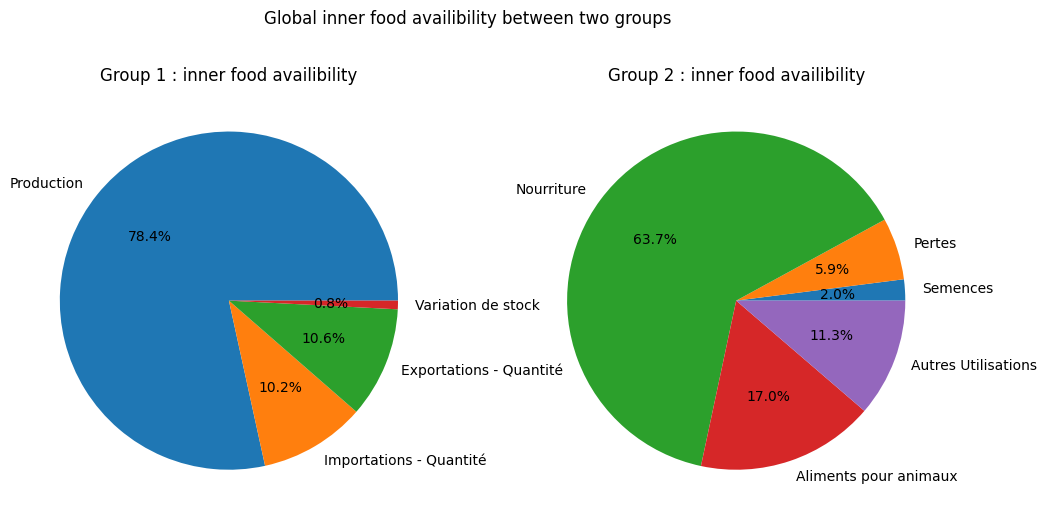

In [ ]:
n_cols = 2
nrows = nrows_plot(n_cols, len([group_1_inner_food_availibility, group_2_inner_food_availibility]))
fig, ax = plt.subplots(nrows, n_cols, figsize=(12,6))

ax[0].pie(
    group_1_inner_food_availibility,
    labels=group1_labels,
    autopct="%1.1f%%",
)
ax[0].set_title("Group 1 : inner food availibility")

ax[1].pie(
    group_2_inner_food_availibility,
    labels=group2_labels,
    autopct="%1.1f%%",
)
ax[1].set_title("Group 2 : inner food availibility")

fig.suptitle("Global inner food availibility between two groups")
plt.show()

À partir des diagrammes circulaires, la répartition globale des métriques apparaît décalée. La production représente la part écrasante de la disponibilité alimentaire, ce qui indique que la majeure parte de la nourriture provient de la production interne plutôt que des importations ou des exportations. Sur le second diagramme (group2), la nourriture destinée à la consommation humaine détient la plus grande part, suivie de celle destinée aux animaux, aux autres usages et aux pertes. Bien que la part dédiée à la nourriture humaine soit la plus importante, elle reste néanmoins insuffisante pour couvrir les besoins de base mondiaux en termes de kilocalories journalières.

## **Est-ce qu'il y a un lien qui existe entre la disponbilité alimentaire et la sous-nutrition ?**

Nous souhaitons évaluer s'il existe une corrélation entre la disponibilité alimentaire et la sous-alimentation.
Nous allons donc formuler deux hypothèses et réaliser un test de Pearson ou de Spearman, car nous travaillons avec deux variables numériques et des groupes indépendants :

- H₀ : Il n'existe aucun lien entre la disponibilité alimentaire et la population sous-alimentée. Les deux variables sont indépendantes.
- H₁ : Un lien existe entre ces deux variables.

In [ ]:
columns = ["Population en sous-nutrition", "Disponibilité alimentaire (Kcal/personne/jour)"]

Éviter les valeurs 0 qui pourraient rendre nos résultats nuls.

In [ ]:
# we will remove the 0 that clearly falsen the data
df_correlations_food_undernourishment = df_sous_nutrition_disponibilite[
    (df_sous_nutrition_disponibilite[columns]>0.0).all(axis=1)
]

In [ ]:
df_correlations_food_undernourishment[columns]

,Population en sous-nutrition,Disponibilité alimentaire (Kcal/personne/jour)
0,10500000.0,5.0
1,10500000.0,1.0
2,10500000.0,1.0
4,10500000.0,4.0
5,10500000.0,23.0
...,...,...
13406,6500000.0,28.0
13407,6500000.0,344.0
13408,6500000.0,46.0
13409,6500000.0,1.0


Visualiser, à l'aide d'un nuage de points, comment les deux caractéristiques interagissent entre elles. Observons-nous une corrélation positive, négative ou sans tendance particulière ?

<Axes: xlabel='Population en sous-nutrition', ylabel='Disponibilité alimentaire (Kcal/personne/jour)'>

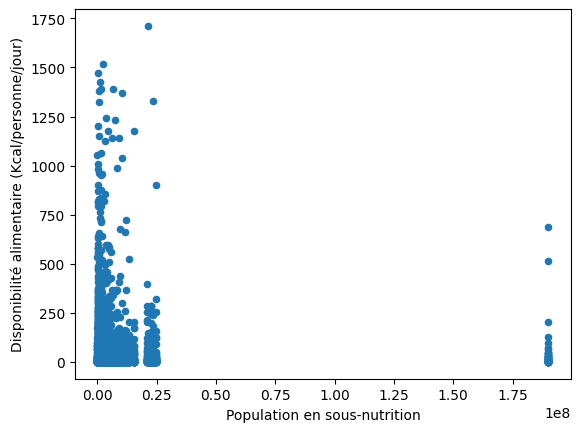

In [ ]:
df_correlations_food_undernourishment.plot(
    kind="scatter",
    x=columns[0],
    y=columns[1]
)

Pas de corrélation particulière observée entre les deux champs. Mais poussons notre analyse plus avec d'autres tests.

Le choix d'un test statistique par rapport à un autre dépend de la distribution des données. Si les données sont normalement distribuées, le coefficient de corrélation de Pearson est adapté ; toutefois, si ce n’est pas le cas, la corrélation de rang de Spearman fournira une évaluation plus robuste.

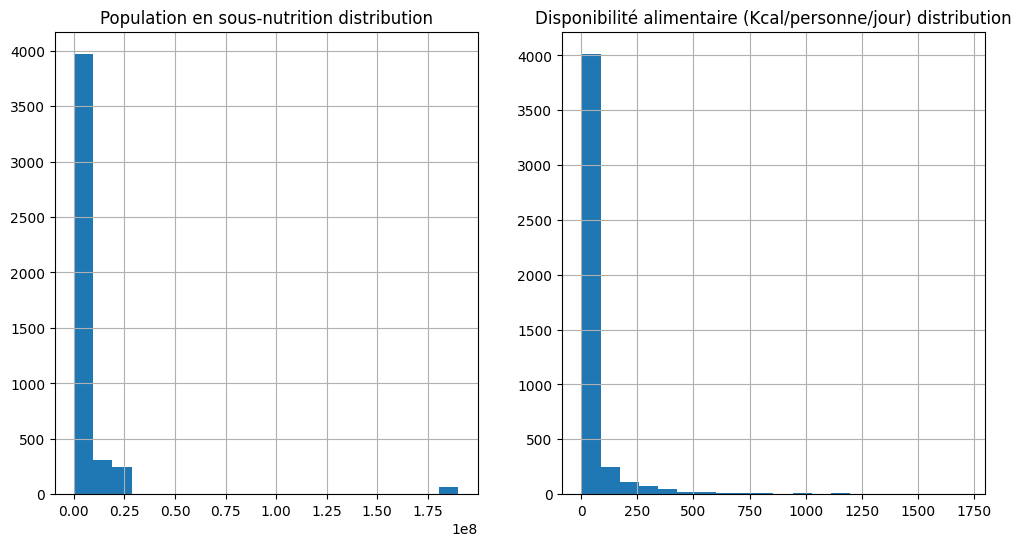

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for i, col in enumerate(columns):
  df_correlations_food_undernourishment[col].hist(
    bins=20,
    ax=axes[i]
  )
  axes[i].set_title(f"{col} distribution")

Pas de distribution uniforme aavec un grand nombre de données du côté gauche

In [ ]:
stats, p_value = spearmanr(df_correlations_food_undernourishment[columns[0]],
                           df_correlations_food_undernourishment[columns[1]])

In [ ]:
stats, p_value

(np.float64(-0.027006743668134905), np.float64(0.0675594830235801))

In [ ]:
if (p_value < 0.05)==True:
  print("Food availibility and undernourishment does have a link")
else:
  print("We cannot assume that food availibility and undernourishment do have a link")

We cannot assume that food availibility and undernourishment do have a link


Comme le confirme la visualisation, la disponibilité alimentaire et la sous-alimentation ne sont pas corrélées. Par conséquent, nous ne pouvons pas supposer qu'un nombre plus élevé de personnes sous-alimentées corresponde à une augmentation de l'apport calorique, ni inversement.

## **Analyse : les pays avec le meilleur taux de disponibilité alimentaire**

In [ ]:
countries_food_availibility= df_dispo_alimentaire.groupby("Pays").agg(
    Total_disponibilite_alimentaire=("Disponibilité alimentaire (Kcal/personne/jour)", "sum")
)

In [ ]:
top_countries_food_availibility = countries_food_availibility\
.sort_values("Total_disponibilite_alimentaire", ascending=False).head(10)

## **Analyse: Les pays avec le pire taux de disponbilité alimentaire**

In [ ]:
bottom_countries_food_availibility = countries_food_availibility\
.sort_values("Total_disponibilite_alimentaire", ascending=False).tail(10)

In [ ]:
top_bottom_countries_food_availibility = pd.concat([
  top_countries_food_availibility,
 bottom_countries_food_availibility], axis=1)

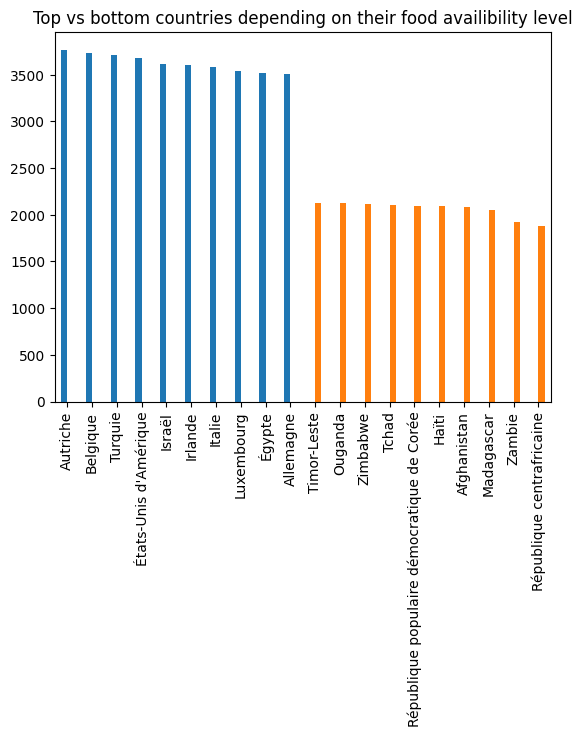

In [ ]:
top_bottom_countries_food_availibility.plot(kind="bar", legend=False)
plt.title("Top vs bottom countries depending on their food availibility level")
plt.xlabel("")
plt.show()

Cette visualisation met de manière significative en évidence l'écart important entre les pays développés et les pays en développement. Alors que les pays développés bénéficient d'une disponibilité calorique largement supérieure à leurs besoins, les pays les plus pauvres se situent souvent légèrement au-dessus de 2000 kcal, un niveau jugé insuffisant selon les recommandations officielles de minimum quotidien en calories.
Sur le plan géographique, ces pays appauvris se trouvent principalement en Afrique, tandis que les pays les plus riches se concentrent généralement en Europe ou en Amérique du Nord.

## **Analyse: Comment les céréales sont repartis entre l'alimentation humaine et animale**

This section is relevant to understanding how cereals are distrbuted between the two main actors within a country.

In [ ]:
df_dispo_alimentaire["Origine"].value_counts()

,count
Origine,
vegetale,11896
animale,3709


In [ ]:
# What are the main cereales
df_dispo_alimentaire.where(
    df_dispo_alimentaire["Origine"] == "vegetale"
)["Produit"].unique()

array([nan, 'Agrumes, Autres', 'Aliments pour enfants', 'Ananas',
       'Bananes', 'Bière', 'Blé', 'Boissons Alcooliques', 'Café',
       'Coco (Incl Coprah)', 'Céréales, Autres', 'Dattes',
       'Edulcorants Autres', 'Feve de Cacao', 'Fruits, Autres',
       'Graines de coton', 'Graines de tournesol',
       'Huil Plantes Oleif Autr', 'Huile Graines de Coton',
       "Huile d'Arachide", "Huile d'Olive", 'Huile de Colza&Moutarde',
       'Huile de Palme', 'Huile de Soja', 'Huile de Sésame',
       'Huile de Tournesol', 'Légumes, Autres', 'Légumineuses Autres',
       'Maïs', 'Miel', 'Millet', 'Miscellanees', 'Noix', 'Olives',
       'Oranges, Mandarines', 'Orge', 'Plantes Oleiferes, Autre',
       'Poivre', 'Pommes', 'Pommes de Terre', 'Raisin',
       'Riz (Eq Blanchi)', 'Sucre Eq Brut', 'Sucre, betterave',
       'Sucre, canne', 'Sésame', 'Thé', 'Tomates', 'Vin',
       'Épices, Autres', 'Alcool, non Comestible',
       'Arachides Decortiquees', 'Avoine', 'Bananes plantains',
     

In [ ]:
# Liste avec les principales céréales
main_cereales = ["Blé", "Riz (Eq Blanchi)",
                 'Maïs',
                 "Millet",
                 "Orge",
                 "Céréales, Autres",
                 "Avoine",
                 "Seigle",
                 "Sorgho"]

In [ ]:
df_cereales_humans_animals = df_dispo_alimentaire[df_dispo_alimentaire["Produit"].isin(main_cereales)]
df_cereales_humans_animals = df_cereales_humans_animals.groupby("Produit").agg(
    Animal_diet=("Aliments pour animaux", "mean"),
    Human_diet=("Nourriture", "mean")
)

df_cereales_humans_animals

,Animal_diet,Human_diet
Produit,,
Avoine,9.731138e+04,2.337126e+04
Blé,7.452184e+05,2.631172e+06
"Céréales, Autres",1.106686e+05,3.095349e+04
Maïs,3.138598e+06,7.194483e+05
Millet,2.119231e+04,1.476923e+05
Orge,5.355954e+05,3.927168e+04
Riz (Eq Blanchi),1.930690e+05,2.168310e+06
Seigle,5.328289e+04,3.619737e+04
Sorgho,1.600516e+05,1.558258e+05


In [ ]:
df_cereales_humans_animals["Animal_diet %"] = df_cereales_humans_animals["Animal_diet"]\
 / df_cereales_humans_animals[["Animal_diet", "Human_diet"]].sum(axis=1)*100

In [ ]:
df_cereales_humans_animals["Human_diet %"] = df_cereales_humans_animals["Human_diet"]\
 / df_cereales_humans_animals[["Animal_diet", "Human_diet"]].sum(axis=1)*100

Text(0.5, 1.0, 'Animal diet vs Human diet')

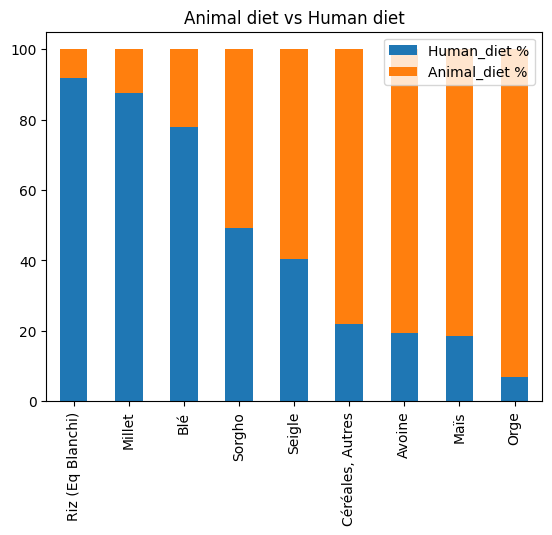

In [ ]:
df_cereales_humans_animals_sorted = df_cereales_humans_animals[["Human_diet %", "Animal_diet %"]]\
.sort_values("Human_diet %", ascending=False)

df_cereales_humans_animals_sorted.plot(kind="bar", stacked=True)
plt.xlabel("")
plt.title("Animal diet vs Human diet")

D'après le graphique en barres empilées représentant la répartition en pourcentage entre alimentation humaine et alimentation animale, le riz blanc est le céréale le plus représentatif, suivi du millet et, de façon surprenante, du blé. Les autres céréales sont principalement consommées par les animaux, en particulier le maïs et l'orge.
Les problèmes mis en évidence montrent que les animaux consomment une quantité excessive de céréales, alors qu'ils pourraient bénéficier d'une alimentation plus adaptée. Ainsi, rééquilibrer la consommation de céréales en faveur de l'alimentation humaine pourrait constituer une solution plus efficace à la fois pour une meilleure santé animale et pour une disponibilité alimentaire accrue pour les êtres humains.

In [ ]:
animal_diet_global = df_cereales_humans_animals["Animal_diet"].sum()
human_diet_global = df_cereales_humans_animals["Human_diet"].sum()

den = animal_diet_global + human_diet_global

In [ ]:
animal_diet_ratio = animal_diet_global / den
print(f"Animal diet ratio: {animal_diet_ratio*100:.2f}%")

Animal diet ratio: 45.92%


In [ ]:
human_diet_ratio = human_diet_global / den
print(f"Human diet ratio: {human_diet_ratio*100:.2f}%")

Human diet ratio: 54.08%


In [ ]:
ratios = [animal_diet_ratio, human_diet_ratio]

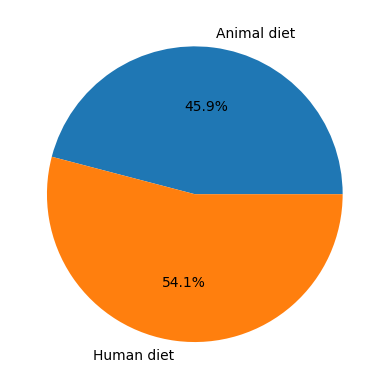

In [ ]:
plt.pie(
    ratios,
    labels=["Animal diet", "Human diet"],
    autopct="%1.1f%%"
)
plt.title("")
plt.show()

Ce diagramme circulaire illustre la répartition mondiale de la consommation de céréales entre l'alimentation humaine et l'alimentation animale. Il montre clairement que l'alimentation humaine représente la part la plus importante, avec 54,1%, contre 45,9% pour l'alimentation animale.

En réalité, un peu plus de la moitié des céréales est donc consommée par les humains. Cependant, même si la part attribuée aux humains est la plus grande, elle devrait être encore plus importante, car la part réservée aux animaux ne sert qu'à leur exploitation.

# **Countries that received highest quantities of food supply**

This section primarily focuses on identifying the top countries that received the highest quantities of food aid and how it varied between 2013 and 2016.

In [ ]:
df_aide_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Pays                          1475 non-null   object
 1   Année                         1475 non-null   int64 
 2   Produit                       1475 non-null   object
 3   Aide alimentaire (en Tonnes)  1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


Filter the dataset to display only years between 2013 and 2016

In [ ]:
year_food_supply = df_aide_alimentaire[
    (df_aide_alimentaire["Année"] >= 2013) &
    (df_aide_alimentaire["Année"] <= 2016)]
year_food_supply

,Pays,Année,Produit,Aide alimentaire (en Tonnes)
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504
...,...,...,...,...
1470,Zimbabwe,2015,Mélanges et préparations,96
1471,Zimbabwe,2013,Non-céréales,5022
1472,Zimbabwe,2014,Non-céréales,2310
1473,Zimbabwe,2015,Non-céréales,306


In [ ]:
grouped_country_year_food_supply = year_food_supply.groupby(["Pays"], as_index=False)[
    "Aide alimentaire (en Tonnes)"
].mean()
top_5_countries_food_supply = grouped_country_year_food_supply.sort_values("Aide alimentaire (en Tonnes)", ascending=False).head(5)

In [ ]:
top_country_supply_food = df_aide_alimentaire[df_aide_alimentaire["Pays"].isin(list(top_5_countries_food_supply["Pays"]))]

['Éthiopie', 'République arabe syrienne', 'Soudan', 'Soudan du Sud', 'Yémen']

In [ ]:
Print(f"Liste des 5 pays avec le plus d'aide alimenraire: {list(top_country_supply_food["Pays"].unique()}")

['Éthiopie', 'République arabe syrienne', 'Soudan', 'Soudan du Sud', 'Yémen'] are the top 5 countries who get the highest volume of aids between 2013 and 2016

In [ ]:
# we need to reverse the dataset
pivot_country_year_food_supply = top_country_supply_food.pivot_table(
    index="Année",
    columns="Pays",
    values="Aide alimentaire (en Tonnes)"
)

<Axes: xlabel='Année'>

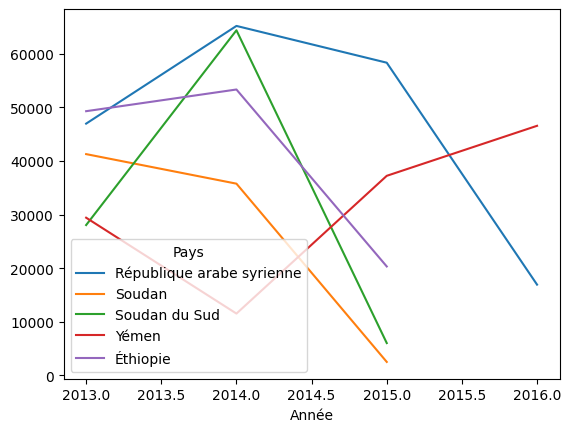

In [ ]:
pivot_country_year_food_supply.plot()

Parmi les 5 pays ayant reçu le plus d’approvisionnement alimentaire international entre 2013 et 2016, le Yémen est le seul dont la part a augmenté à cette période.

## Etude de cas: Le Manioc en Thailande

Cette étude de cas est significative pour évaluer comment un scénario précis illustre le fait que certains pays privilégient des stratégies d’exportation au détriment des besoins de leur propre population.

In [ ]:
# Filtrage sur le pays = Thailande
df_thailand = df_sous_nutrition_disponibilite[df_sous_nutrition_disponibilite["Pays"]=="Thaïlande"]
df_thailand

,Pays,Année,Population en sous-nutrition,Année médian,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,_merge
12564,Thaïlande,2016-2018,6200000.0,2017,Abats Comestible,animale,0.0,0.0,3.0,1.11,...,74000.0,5000.0,33000.0,75000.0,0.0,45000.0,0.0,0.0,0.0,both
12565,Thaïlande,2016-2018,6200000.0,2017,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,...,8000.0,6000.0,2000.0,6000.0,0.0,12000.0,0.0,2000.0,0.0,both
12566,Thaïlande,2016-2018,6200000.0,2017,"Alcool, non Comestible",vegetale,0.0,358000.0,0.0,0.00,...,358000.0,110000.0,21000.0,0.0,0.0,447000.0,0.0,0.0,0.0,both
12567,Thaïlande,2016-2018,6200000.0,2017,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,...,12000.0,7000.0,19000.0,12000.0,0.0,0.0,0.0,0.0,0.0,both
12568,Thaïlande,2016-2018,6200000.0,2017,Ananas,vegetale,0.0,0.0,10.0,10.02,...,782000.0,1449000.0,9000.0,671000.0,110000.0,2209000.0,0.0,0.0,13000.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12654,Thaïlande,2016-2018,6200000.0,2017,Viande de Suides,animale,0.0,0.0,124.0,13.00,...,871000.0,22000.0,1000.0,871000.0,0.0,891000.0,0.0,0.0,0.0,both
12655,Thaïlande,2016-2018,6200000.0,2017,Viande de Volailles,animale,0.0,0.0,52.0,13.69,...,945000.0,536000.0,11000.0,917000.0,28000.0,1470000.0,0.0,0.0,0.0,both
12656,Thaïlande,2016-2018,6200000.0,2017,"Viande, Autre",animale,0.0,0.0,0.0,0.03,...,-92000.0,96000.0,4000.0,2000.0,0.0,0.0,0.0,0.0,0.0,both
12657,Thaïlande,2016-2018,6200000.0,2017,Vin,vegetale,0.0,0.0,0.0,0.12,...,8000.0,8000.0,16000.0,8000.0,0.0,0.0,0.0,0.0,0.0,both


In [ ]:
# Deuxième filtrage sur le manioc
df_thailand_manioc = df_thailand[df_thailand["Produit"]=="Manioc"]
df_thailand_manioc

,Pays,Année,Population en sous-nutrition,Année médian,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,_merge
12614,Thaïlande,2016-2018,6200000.0,2017,Manioc,vegetale,1800000.0,2081000.0,40.0,13.0,...,6264000.0,25214000.0,1250000.0,871000.0,1511000.0,30228000.0,0.0,0.0,0.0,both


### **Importations et exportations de la Thailande

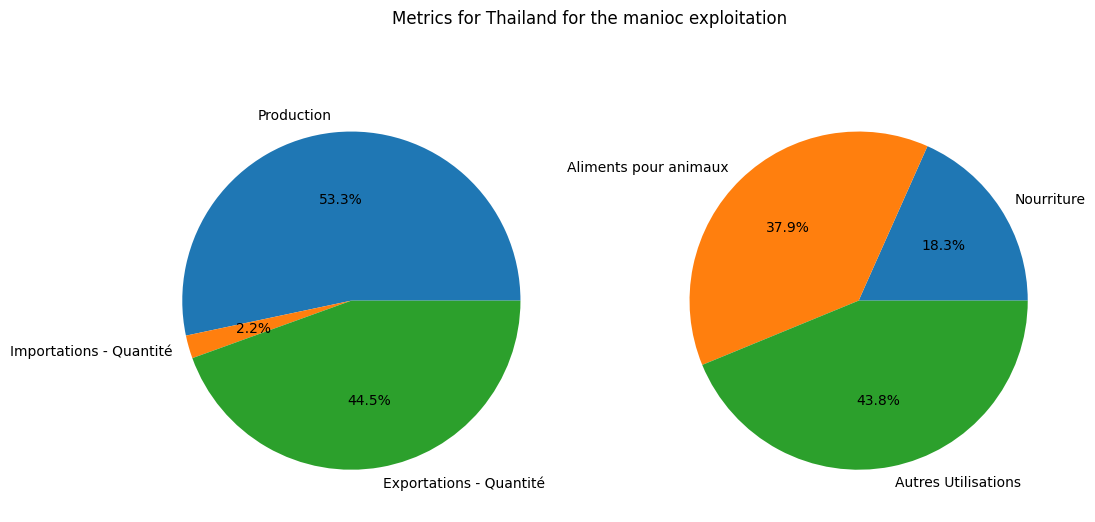

In [ ]:
fig, axis = plt.subplots(1, 2, figsize=(12, 6))
ax = axis.flatten()
ax[0].pie(
    df_thailand_manioc.loc[:,
                           ["Production", "Importations - Quantité", "Exportations - Quantité"]
                           ].iloc[0].abs().values,
    labels=df_thailand_manioc.loc[:, ["Production", "Importations - Quantité", "Exportations - Quantité"]].columns,
    autopct="%1.1f%%"
)

ax[1].pie(
    df_thailand_manioc.loc[:,
                           ["Nourriture", "Aliments pour animaux", "Autres Utilisations"]
                           ].iloc[0].abs().values,
    labels=df_thailand_manioc.loc[:, ["Nourriture", "Aliments pour animaux", "Autres Utilisations"]].columns,
    autopct="%1.1f%%"
)

fig.suptitle("Metrics for Thailand for the manioc exploitation")

plt.show()

La production de manioc représente plus de la moitié de la disponibilité alimentaire, mais près de la moitié du manioc est exportée, une petite part seulement étant importée. Plus surprenant encore, alors que certaines personnes en Thaïlande ne couvrent pas leurs besoins énergétiques minimum, moins de 20% de la production est destinée à la consommation humaine, le reste étant utilisé pour l’alimentation animale et d’autres usages.

## **Analyses complémentaires**

### **Pays champion de l'importation**

In [ ]:
grouped_countries_imports = df_dispo_alimentaire.groupby("Pays")["Importations - Quantité"].sum()

In [ ]:
top_countries_imports = grouped_countries_imports.sort_values(ascending=False).head(10)

Text(0.5, 0, '')

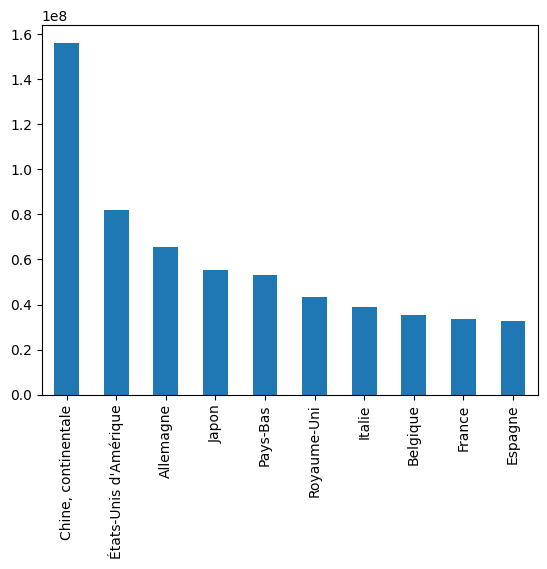

In [ ]:
top_countries_imports.plot(kind="bar")
plt.xlabel("")

### **Top pays producteurs**

In [ ]:
grouped_countries_production = df_dispo_alimentaire.groupby("Pays")["Production"].sum()

In [ ]:
top_countries_production = grouped_countries_production.sort_values(ascending=False).head(10)

<Axes: xlabel='Pays'>

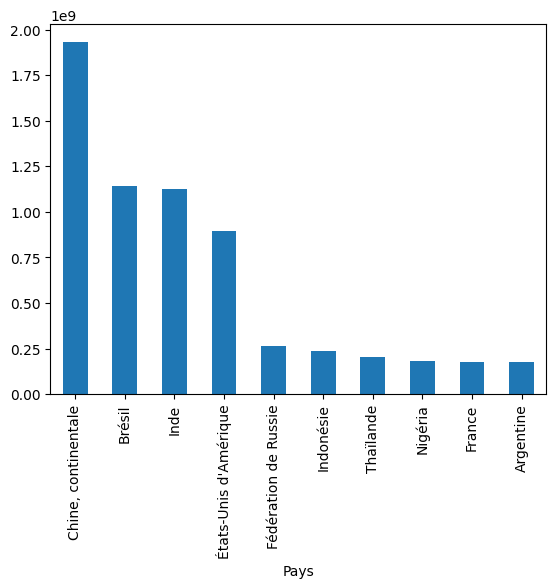

In [ ]:
top_countries_production.plot(kind="bar")

La Chine, le Brésil, l'Inde, les États-Unis et la Russie figurent parmi les plus grands pays producteurs, un fait largement attribuable à leur vaste superficie agricole.

### **Pays qui ont le plus de pertes**

In [ ]:
grouped_countries_losses = df_dispo_alimentaire.groupby("Pays")["Pertes"].sum()

In [ ]:
top_countries_losses = grouped_countries_losses.sort_values(ascending=False).head(10).reset_index()

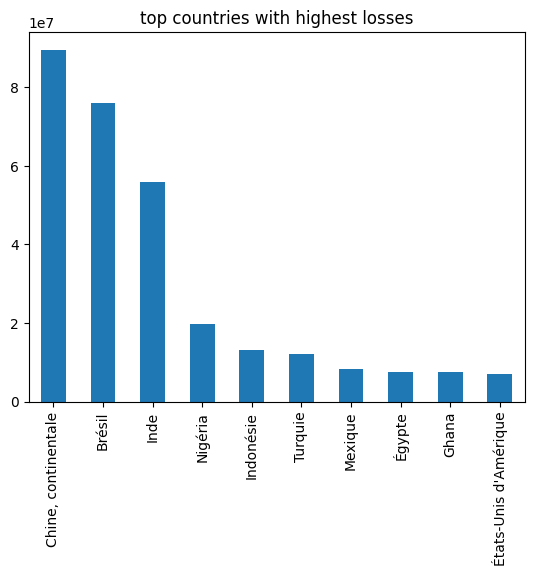

In [ ]:
top_countries_losses.plot(kind="bar", x="Pays", legend=False)
plt.xlabel("")
plt.title("top countries with highest losses")
plt.show()

La Chine, le Brésil et l’Inde se situent dans le même ordre de grands pays producteurs, mais ils sont également ceux dont les pertes sont les plus élevées. Seuls les États‑Unis, considérés comme un grand pays producteur, disposent d’un système de pertes plus optimisé.

# Conclusion générale

Globalement, la production alimentaire, si elle était bien répartie, serait largement suffisante pour couvrir les besoins de tous les habitants. Toutefois, la réalité est bien différente, et des inégalités importantes subsistent entre les pays développés et les autres. La manière de répartir la production entre les différentes catégories est aussi critiquable, lorsque la production est utilisée à d'autres fins que celle de nourrir la population.

Il existe également des inégalités naturelles: certaines zones en sous-nutrition ne bénéficient pas d'un climat ou de terrains leur permettant d'être autosuffisantes, et elles dépendent fortement soit des importations, soit de l'aide alimentaire.